# 03 — Preparação dos Dados para Modelagem

Este notebook transforma a base auditada na etapa anterior em uma **base estruturada para modelagem supervisionada**.

A preparação segue quatro princípios:

1. utilizar somente reclamações com desfecho conhecido (`Resolvida` ou `Não Resolvida`) para treinamento e avaliação;
2. definir `Resolvida` como classe positiva (`target = 1`);
3. impedir o uso de informações indisponíveis no momento da predição ou associadas ao desfecho da reclamação;
4. preservar a ordem temporal da base, construindo os conjuntos de **treino**, **teste** e **out-of-time (OOT)**.

### O que este notebook ainda não faz

Nesta etapa **não** serão realizados:

- *one-hot encoding*;
- padronização ou normalização;
- imputação aprendida a partir dos dados;
- seleção de atributos baseada no desempenho do modelo;
- treinamento de classificadores.

Essas transformações serão implementadas posteriormente dentro de *pipelines* ajustados exclusivamente com os dados de treino, reduzindo o risco de *data leakage*.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Diretórios do projeto


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")
BASE_DIR = PROJECT_DIR / "Base de dados"
PROCESSADOS_DIR = BASE_DIR / "processados"

FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"

PROCESSADOS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# O nome principal esperado é dataset.csv.
# Mantém-se um fallback para o nome utilizado em versões anteriores do projeto.
candidatos = [
    PROCESSADOS_DIR / "dataset.csv",
    PROCESSADOS_DIR / "dataset_banco_brasil_puro.csv",
]

INPUT_FILE = next((arquivo for arquivo in candidatos if arquivo.exists()), None)

if INPUT_FILE is None:
    raise FileNotFoundError(
        "Dataset consolidado não encontrado em "
        f"{PROCESSADOS_DIR}."
    )

OUTPUT_MODELAGEM = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"
OUTPUT_NAO_AVALIADAS = PROCESSADOS_DIR / "dataset_nao_avaliadas_aplicacao.csv"

print(f"Entrada: {INPUT_FILE}")
print(f"Saída modelagem: {OUTPUT_MODELAGEM}")
print(f"Saída não avaliadas: {OUTPUT_NAO_AVALIADAS}")


Entrada: C:\UnB\script_md\Base de dados\processados\dataset.csv
Saída modelagem: C:\UnB\script_md\Base de dados\processados\dataset_modelagem_preparado.csv
Saída não avaliadas: C:\UnB\script_md\Base de dados\processados\dataset_nao_avaliadas_aplicacao.csv


## 3. Carregamento e validação da base de origem

Antes de qualquer preparação, verificamos se a base recebida possui a estrutura esperada e se a variável temporal corrigida está íntegra.


In [3]:
df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Dimensão da base de origem: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

Dimensão da base de origem: 209,870 linhas x 22 colunas


In [4]:
colunas_obrigatorias = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Data Finalização",
    "Tempo Resposta",
    "Nome Fantasia",
    "Segmento de Mercado",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa",
    "Respondida",
    "Situação",
    "Avaliação Reclamação",
    "Nota do Consumidor",
    "AAAA_MM"
]

colunas_ausentes = [
    coluna for coluna in colunas_obrigatorias
    if coluna not in df.columns
]

if colunas_ausentes:
    raise KeyError(
        f"Colunas obrigatórias ausentes: {colunas_ausentes}"
    )

# Valida a variável temporal construída no notebook 01.
if df["AAAA_MM"].isna().sum() > 0:
    raise ValueError(
        f"AAAA_MM possui {df['AAAA_MM'].isna().sum():,} valores nulos. "
        "Execute novamente o notebook 01 corrigido antes de prosseguir."
    )

if df["AAAA_MM"].nunique() != 48:
    raise ValueError(
        f"Foram encontrados {df['AAAA_MM'].nunique()} meses, "
        "mas são esperados 48."
    )

print("Validação da base concluída.")
print(f"Período inicial: {df['AAAA_MM'].min()}")
print(f"Período final:   {df['AAAA_MM'].max()}")
print(f"Meses distintos: {df['AAAA_MM'].nunique()}")


Validação da base concluída.
Período inicial: 2022_08
Período final:   2026_07
Meses distintos: 48


## 4. Definição da população supervisionada

A variável original `Avaliação Reclamação` possui três categorias:

- `Resolvida`;
- `Não Resolvida`;
- `Não Avaliada`.

As observações `Não Avaliada` não representam a classe negativa. Elas correspondem a reclamações para as quais não há desfecho informado pelo consumidor e, portanto, **não serão utilizadas no treinamento supervisionado**.

Esses registros são preservados separadamente para eventual aplicação posterior do modelo.


In [5]:
categorias_modelagem = ["Resolvida", "Não Resolvida"]

df_modelagem = df[
    df["Avaliação Reclamação"].isin(categorias_modelagem)
].copy()

df_nao_avaliadas = df[
    df["Avaliação Reclamação"].eq("Não Avaliada")
].copy()

n_total = len(df)
n_modelagem = len(df_modelagem)
n_nao_avaliadas = len(df_nao_avaliadas)

resumo_amostras = pd.DataFrame({
    "Amostra": [
        "Base original",
        "Amostra supervisionada",
        "Não avaliadas (reservadas)"
    ],
    "Registros": [
        n_total,
        n_modelagem,
        n_nao_avaliadas
    ],
    "Percentual da base (%)": [
        100.0,
        n_modelagem / n_total * 100,
        n_nao_avaliadas / n_total * 100
    ]
})

resumo_amostras["Percentual da base (%)"] = (
    resumo_amostras["Percentual da base (%)"].round(2)
)

display(resumo_amostras)


,Amostra,Registros,Percentual da base (%)
0,Base original,209870,100.00
1,Amostra supervisionada,58131,27.70
2,Não avaliadas (reservadas),151739,72.30


In [6]:
resumo_amostras.to_csv(
    TABLES_DIR / "preparacao_resumo_amostras.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


## 5. Construção da variável-alvo binária

A classe de interesse da pesquisa é `Resolvida`.

A codificação adotada será:

- `Resolvida` → `1`;
- `Não Resolvida` → `0`.

A variável original é mantida na base preparada para facilitar auditorias e interpretação dos resultados.


In [7]:
mapeamento_target = {
    "Resolvida": 1,
    "Não Resolvida": 0
}

df_modelagem["target"] = (
    df_modelagem["Avaliação Reclamação"]
    .map(mapeamento_target)
    .astype("int8")
)

assert df_modelagem["target"].isna().sum() == 0
assert set(df_modelagem["target"].unique()) == {0, 1}

distribuicao_target = pd.DataFrame({
    "Classe": ["Resolvida", "Não Resolvida"],
    "Código": [1, 0],
    "Registros": [
        int((df_modelagem["target"] == 1).sum()),
        int((df_modelagem["target"] == 0).sum())
    ]
})

distribuicao_target["Percentual (%)"] = (
    distribuicao_target["Registros"]
    .div(distribuicao_target["Registros"].sum())
    .mul(100)
    .round(2)
)

display(distribuicao_target)


,Classe,Código,Registros,Percentual (%)
0,Resolvida,1,20050,34.49
1,Não Resolvida,0,38081,65.51


## 6. Decisão sobre as variáveis disponíveis

Antes de montar a matriz preditiva, cada variável é classificada segundo seu papel no estudo.

A regra central é: **o modelo deve utilizar apenas informações disponíveis antes do desfecho que se pretende prever**.

Variáveis produzidas durante ou após o tratamento da reclamação não devem funcionar como preditores.


In [9]:
decisao_variaveis = pd.DataFrame([
    ["Região", "Preditor", "Manter", "Característica geográfica disponível na reclamação."],
    ["UF", "Preditor", "Manter", "Característica geográfica disponível na reclamação."],
    ["Cidade", "Preditor", "Manter", "Característica geográfica disponível; alta cardinalidade será tratada no pipeline."],
    ["Sexo", "Preditor", "Manter", "Característica disponível na entrada da reclamação."],
    ["Faixa Etária", "Preditor", "Manter", "Característica disponível na entrada da reclamação."],
    ["Data Finalização", "Controle temporal", "Não usar como preditor", "O momento de finalização não é conhecido no instante da predição."],
    ["Tempo Resposta", "Pós-evento", "Excluir", "É produzido durante o tratamento e pode introduzir data leakage."],
    ["Nome Fantasia", "Filtro", "Excluir", "Após o filtro possui apenas um valor: Banco do Brasil."],
    ["Segmento de Mercado", "Constante", "Excluir", "Após o filtro possui apenas um valor."],
    ["Área", "Preditor", "Manter", "Característica do conteúdo da reclamação."],
    ["Assunto", "Preditor", "Manter", "Característica do conteúdo da reclamação."],
    ["Grupo Problema", "Preditor", "Manter", "Característica do problema relatado."],
    ["Problema", "Preditor", "Manter", "Característica do problema relatado."],
    ["Como Comprou Contratou", "Preditor", "Manter", "Característica disponível na reclamação."],
    ["Procurou Empresa", "Preditor", "Manter", "Informação declarada pelo consumidor no registro da reclamação."],
    ["Respondida", "Pós-evento", "Excluir", "Reflete ação ocorrida durante o tratamento da reclamação."],
    ["Situação", "Desfecho administrativo", "Excluir", "Distingue diretamente reclamações avaliadas e não avaliadas."],
    ["Avaliação Reclamação", "Variável-alvo original", "Não usar como preditor", "Origina a target binária."],
    ["Nota do Consumidor", "Pós-desfecho", "Excluir", "É atribuída pelo consumidor após o tratamento e está diretamente associada ao desfecho."],
    ["Interação com Judiciario", "Disponibilidade inconsistente", "Excluir nesta fase", "Apresenta elevada ausência e disponibilidade temporal inconsistente na base."],
    ["Último Complemento Consumidor", "Pós-evento / alta ausência", "Excluir nesta fase", "Possui elevada ausência e representa interação posterior ao registro inicial."],
    ["AAAA_MM", "Controle temporal", "Não usar como preditor", "Será utilizado exclusivamente para o particionamento temporal."],
    ["target", "Variável-alvo", "Target", "1 = Resolvida; 0 = Não Resolvida."]
], columns=[
    "Variável",
    "Papel",
    "Decisão",
    "Justificativa"
])

display(decisao_variaveis)


,Variável,Papel,Decisão,Justificativa
0,Região,Preditor,Manter,Característica geográfica disponível na reclamação.
1,UF,Preditor,Manter,Característica geográfica disponível na reclamação.
2,Cidade,Preditor,Manter,Característica geográfica disponível; alta cardinalidade será tratada no pipeline.
3,Sexo,Preditor,Manter,Característica disponível na entrada da reclamação.
4,Faixa Etária,Preditor,Manter,Característica disponível na entrada da reclamação.
5,Data Finalização,Controle temporal,Não usar como preditor,O momento de finalização não é conhecido no instante da predição.
6,Tempo Resposta,Pós-evento,Excluir,É produzido durante o tratamento e pode introduzir data leakage.
7,Nome Fantasia,Filtro,Excluir,Após o filtro possui apenas um valor: Banco do Brasil.
8,Segmento de Mercado,Constante,Excluir,Após o filtro possui apenas um valor.
9,Área,Preditor,Manter,Característica do conteúdo da reclamação.


In [10]:
decisao_variaveis.to_csv(
    TABLES_DIR / "preparacao_decisao_variaveis.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


## 7. Definição dos preditores

A matriz preditiva inicial será composta por atributos disponíveis no registro da reclamação e sem relação direta com seu desfecho posterior.

A seleção abaixo ainda **não representa seleção estatística de atributos**. Ela representa apenas uma seleção metodológica baseada em disponibilidade da informação e prevenção de *data leakage*.


In [11]:
PREDITORES = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

print(f"Quantidade inicial de preditores: {len(PREDITORES)}")
print()
for coluna in PREDITORES:
    print(f"- {coluna}")


Quantidade inicial de preditores: 11

- Região
- UF
- Cidade
- Sexo
- Faixa Etária
- Área
- Assunto
- Grupo Problema
- Problema
- Como Comprou Contratou
- Procurou Empresa


### 7.1 Qualidade dos preditores na amostra supervisionada

Antes de avançar, verificamos ausências e cardinalidade somente na população que efetivamente será utilizada para modelagem.


In [12]:
qualidade_preditores = pd.DataFrame({
    "Tipo": df_modelagem[PREDITORES].dtypes.astype(str),
    "Nulos": df_modelagem[PREDITORES].isna().sum(),
    "Nulos (%)": (
        df_modelagem[PREDITORES]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    ),
    "Categorias": df_modelagem[PREDITORES].nunique(dropna=False)
})

qualidade_preditores = qualidade_preditores.sort_values(
    "Categorias",
    ascending=False
)

display(qualidade_preditores)

qualidade_preditores.to_csv(
    TABLES_DIR / "preparacao_qualidade_preditores.csv",
    sep=";",
    encoding="utf-8-sig"
)


,Tipo,Nulos,Nulos (%),Categorias
Cidade,str,0,0.00,3623
Problema,str,0,0.00,91
Assunto,str,0,0.00,28
UF,str,0,0.00,27
Como Comprou Contratou,str,0,0.00,9
Grupo Problema,str,0,0.00,8
Faixa Etária,str,0,0.00,7
Região,str,0,0.00,5
Sexo,str,0,0.00,3
Área,str,0,0.00,3


In [13]:
nulos_preditores = int(
    df_modelagem[PREDITORES]
    .isna()
    .sum()
    .sum()
)

print(f"Total de valores ausentes nos preditores selecionados: {nulos_preditores:,}")

if nulos_preditores == 0:
    print("Não será necessária imputação para os preditores selecionados nesta amostra.")
else:
    print(
        "Existem valores ausentes. O tratamento deverá ser aprendido "
        "exclusivamente a partir do conjunto de treino."
    )


Total de valores ausentes nos preditores selecionados: 0
Não será necessária imputação para os preditores selecionados nesta amostra.


## 8. Registros com atributos idênticos

Na etapa de qualidade foram identificados registros completamente duplicados.

Entretanto, a base não fornece um identificador único de reclamação. Assim, duas linhas com os mesmos atributos observados podem representar reclamações distintas.

Por esse motivo, **nenhuma duplicata será removida automaticamente nesta etapa**. A decisão evita excluir observações legítimas apenas por coincidência dos campos disponíveis.


In [14]:
duplicadas_supervisionada = int(
    df_modelagem.duplicated().sum()
)

pct_duplicadas_supervisionada = (
    duplicadas_supervisionada / len(df_modelagem) * 100
)

print(
    f"Linhas completamente duplicadas na amostra supervisionada: "
    f"{duplicadas_supervisionada:,}"
)

print(
    f"Percentual na amostra supervisionada: "
    f"{pct_duplicadas_supervisionada:.2f}%"
)

print("Decisão: registros preservados.")


Linhas completamente duplicadas na amostra supervisionada: 134
Percentual na amostra supervisionada: 0.23%
Decisão: registros preservados.


## 9. Particionamento temporal

A avaliação utilizará os 48 meses de dados em ordem cronológica:

- **Treino:** primeiros 24 meses;
- **Teste:** 12 meses subsequentes;
- **Out-of-time (OOT):** últimos 12 meses.

A separação temporal é realizada antes de qualquer transformação aprendida dos dados.


In [15]:
periodos = sorted(
    df_modelagem["AAAA_MM"]
    .dropna()
    .unique()
)

if len(periodos) != 48:
    raise ValueError(
        f"A amostra supervisionada contém {len(periodos)} meses. "
        "Eram esperados 48 meses."
    )

periodos_treino = periodos[:24]
periodos_teste = periodos[24:36]
periodos_oot = periodos[36:48]

def definir_amostra(periodo):
    if periodo in periodos_treino:
        return "Treino"
    if periodo in periodos_teste:
        return "Teste"
    if periodo in periodos_oot:
        return "OOT"
    return np.nan

df_modelagem["Amostra"] = (
    df_modelagem["AAAA_MM"]
    .map(definir_amostra)
)

assert df_modelagem["Amostra"].isna().sum() == 0

print(
    f"Treino: {periodos_treino[0]} a {periodos_treino[-1]} "
    f"({len(periodos_treino)} meses)"
)

print(
    f"Teste:  {periodos_teste[0]} a {periodos_teste[-1]} "
    f"({len(periodos_teste)} meses)"
)

print(
    f"OOT:    {periodos_oot[0]} a {periodos_oot[-1]} "
    f"({len(periodos_oot)} meses)"
)


Treino: 2022_08 a 2024_07 (24 meses)
Teste:  2024_08 a 2025_07 (12 meses)
OOT:    2025_08 a 2026_07 (12 meses)


### 9.1 Tabela dos períodos por partição


In [16]:
tabela_periodos = pd.DataFrame({
    "AAAA_MM": periodos,
    "Amostra": (
        ["Treino"] * 24 +
        ["Teste"] * 12 +
        ["OOT"] * 12
    )
})

display(tabela_periodos)

tabela_periodos.to_csv(
    TABLES_DIR / "preparacao_periodos_particoes.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,AAAA_MM,Amostra
0,2022_08,Treino
1,2022_09,Treino
2,2022_10,Treino
3,2022_11,Treino
4,2022_12,Treino
5,2023_01,Treino
6,2023_02,Treino
7,2023_03,Treino
8,2023_04,Treino
9,2023_05,Treino


## 10. Caracterização das partições temporais

Antes da modelagem, é importante verificar o tamanho de cada amostra e a prevalência da classe positiva em cada período.

Essa caracterização será relevante para interpretar posteriormente eventuais diferenças entre o desempenho no teste e no conjunto OOT.


In [17]:
resumo_particoes = (
    df_modelagem
    .groupby("Amostra", observed=True)
    .agg(
        Registros=("target", "size"),
        Resolvidas=("target", "sum")
    )
)

resumo_particoes["Não Resolvidas"] = (
    resumo_particoes["Registros"] -
    resumo_particoes["Resolvidas"]
)

resumo_particoes["Resolvida (%)"] = (
    resumo_particoes["Resolvidas"]
    .div(resumo_particoes["Registros"])
    .mul(100)
    .round(2)
)

resumo_particoes["Não Resolvida (%)"] = (
    resumo_particoes["Não Resolvidas"]
    .div(resumo_particoes["Registros"])
    .mul(100)
    .round(2)
)

# Ordem lógica das amostras.
resumo_particoes = resumo_particoes.reindex(
    ["Treino", "Teste", "OOT"]
)

display(resumo_particoes)

resumo_particoes.to_csv(
    TABLES_DIR / "preparacao_resumo_particoes.csv",
    sep=";",
    encoding="utf-8-sig"
)


,Registros,Resolvidas,Não Resolvidas,Resolvida (%),Não Resolvida (%)
Amostra,,,,,
Treino,12032,5506,6526,45.76,54.24
Teste,14027,5395,8632,38.46,61.54
OOT,32072,9149,22923,28.53,71.47


### 10.1 Volume de observações por partição


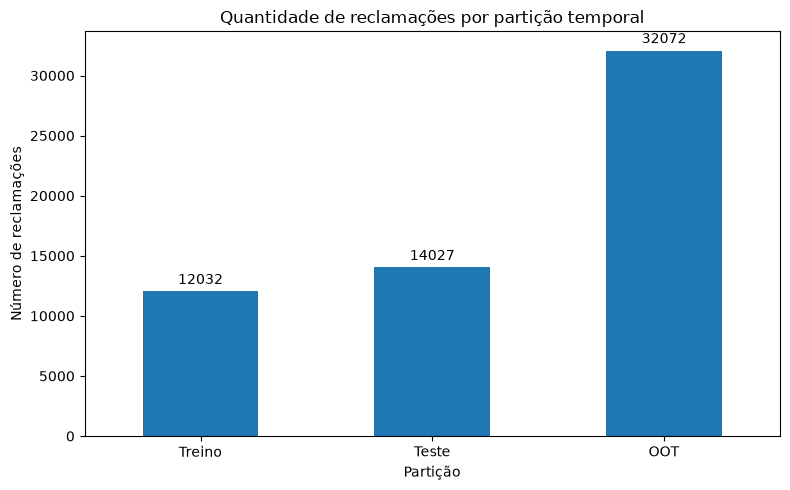

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

resumo_particoes["Registros"].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Quantidade de reclamações por partição temporal")
ax.set_xlabel("Partição")
ax.set_ylabel("Número de reclamações")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "preparacao_volume_particoes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 10.2 Prevalência da classe positiva por partição


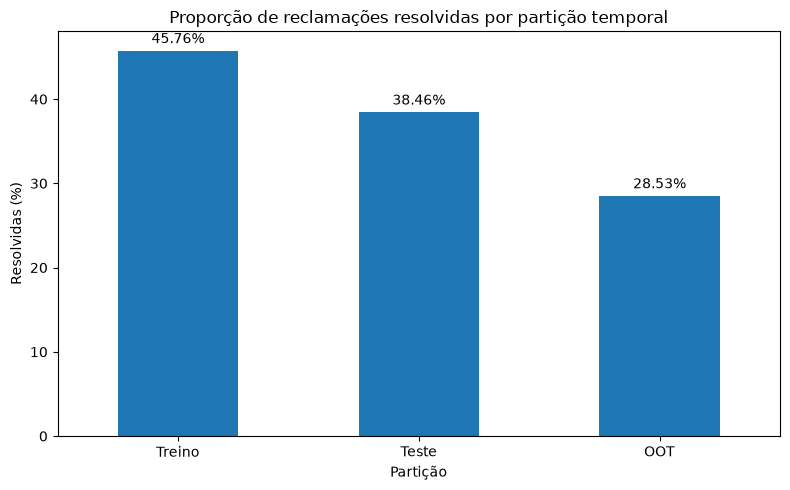

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

resumo_particoes["Resolvida (%)"].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Proporção de reclamações resolvidas por partição temporal")
ax.set_xlabel("Partição")
ax.set_ylabel("Resolvidas (%)")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "preparacao_prevalencia_target_particoes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 11. Construção da base preparada

A base preparada preservará:

- os 11 preditores selecionados;
- `Data Finalização`, apenas para rastreabilidade;
- `AAAA_MM`, para controle temporal;
- `Amostra`, indicando treino, teste ou OOT;
- `Avaliação Reclamação`, para interpretação;
- `target`, utilizada pelos algoritmos.

`Data Finalização`, `AAAA_MM`, `Amostra` e `Avaliação Reclamação` **não deverão ser incluídas na matriz `X` dos modelos**.


In [20]:
COLUNAS_CONTROLE = [
    "Data Finalização",
    "AAAA_MM",
    "Amostra",
    "Avaliação Reclamação",
    "target"
]

colunas_base_modelagem = (
    PREDITORES +
    COLUNAS_CONTROLE
)

df_preparado = (
    df_modelagem[colunas_base_modelagem]
    .copy()
    .sort_values(
        by=["AAAA_MM", "Data Finalização"],
        kind="stable"
    )
    .reset_index(drop=True)
)

print(
    f"Base preparada: {df_preparado.shape[0]:,} linhas x "
    f"{df_preparado.shape[1]} colunas"
)

display(df_preparado.head())


Base preparada: 58,131 linhas x 16 colunas


,Região,UF,Cidade,Sexo,Faixa Etária,Área,Assunto,Grupo Problema,Problema,Como Comprou Contratou,Procurou Empresa,Data Finalização,AAAA_MM,Amostra,Avaliação Reclamação,target
0,SE,RJ,Niterói,F,entre 61 a 70 anos,Serviços Financeiros,Serviço de pagamento online/ via celular/ maquininha,Vício de Qualidade,Funcionamento inadequado do serviço,Internet,S,2022-08-01,2022_08,Treino,Não Resolvida,0
1,N,AM,Manaus,M,entre 61 a 70 anos,Serviços Financeiros,Crédito Consignado (para servidores públicos ou trabalhadores do setor privado),Contrato / Oferta,Não entrega do contrato ou documentação relacionada ao serviço,Loja física,S,2022-08-01,2022_08,Treino,Não Resolvida,0
2,NE,BA,Salvador,F,entre 31 a 40 anos,Serviços Financeiros,Atendimento Bancário,Vício de Qualidade,"Dificuldade de contato ou acesso aos serviços - caixa eletrônico, agência, internet banking",Internet,S,2022-08-01,2022_08,Treino,Resolvida,1
3,N,AP,Macapá,M,entre 51 a 60 anos,Serviços Financeiros,Seguro Prestamista,Cobrança / Contestação,"Cobrança de tarifas, taxas, valores não previstos / não informados",Loja física,N,2022-08-01,2022_08,Treino,Não Resolvida,0
4,SE,MG,Contagem,F,entre 31 a 40 anos,Serviços Financeiros,Conta corrente / Salário / Poupança /Conta Aposentadoria,Cobrança / Contestação,Cobrança indevida / abusiva para alterar ou cancelar o contrato,Não comprei / contratei,S,2022-08-01,2022_08,Treino,Resolvida,1


## 12. Preparação da base de reclamações não avaliadas

As reclamações `Não Avaliada` permanecem fora do desenvolvimento supervisionado.

Entretanto, são preservadas com os mesmos preditores para eventual aplicação posterior do modelo, permitindo explorar o uso operacional da probabilidade estimada de resolução.


In [21]:
colunas_nao_avaliadas = (
    PREDITORES +
    [
        "Data Finalização",
        "AAAA_MM",
        "Avaliação Reclamação"
    ]
)

df_nao_avaliadas_preparado = (
    df_nao_avaliadas[colunas_nao_avaliadas]
    .copy()
    .sort_values(
        by=["AAAA_MM", "Data Finalização"],
        kind="stable"
    )
    .reset_index(drop=True)
)

print(
    f"Base reservada para aplicação futura: "
    f"{df_nao_avaliadas_preparado.shape[0]:,} linhas x "
    f"{df_nao_avaliadas_preparado.shape[1]} colunas"
)


Base reservada para aplicação futura: 151,739 linhas x 14 colunas


## 13. Salvamento dos datasets preparados


In [22]:
df_preparado.to_csv(
    OUTPUT_MODELAGEM,
    sep=";",
    encoding="utf-8-sig",
    index=False
)

df_nao_avaliadas_preparado.to_csv(
    OUTPUT_NAO_AVALIADAS,
    sep=";",
    encoding="utf-8-sig",
    index=False
)

print("Arquivos salvos com sucesso.")
print()
print(f"Modelagem: {OUTPUT_MODELAGEM}")
print(f"Não avaliadas: {OUTPUT_NAO_AVALIADAS}")


Arquivos salvos com sucesso.

Modelagem: C:\UnB\script_md\Base de dados\processados\dataset_modelagem_preparado.csv
Não avaliadas: C:\UnB\script_md\Base de dados\processados\dataset_nao_avaliadas_aplicacao.csv


## 14. Validação final da base preparada

As verificações abaixo funcionam como barreiras de segurança antes de iniciar o pré-processamento e os modelos.


In [23]:
assert len(df_preparado) == len(df_modelagem)
assert df_preparado["target"].isna().sum() == 0
assert set(df_preparado["target"].unique()) == {0, 1}
assert df_preparado["AAAA_MM"].isna().sum() == 0
assert df_preparado["Amostra"].isna().sum() == 0
assert set(df_preparado["Amostra"].unique()) == {"Treino", "Teste", "OOT"}

# Os preditores definidos metodologicamente devem estar presentes.
assert all(
    coluna in df_preparado.columns
    for coluna in PREDITORES
)

print("Todas as validações foram concluídas sem erro.")


Todas as validações foram concluídas sem erro.


## 15. Síntese para Resultados e Discussões

O texto abaixo é produzido automaticamente a partir da preparação dos dados. Ele constitui apoio para a futura redação do artigo e deverá ser interpretado conjuntamente com os resultados dos modelos.


In [24]:
treino = resumo_particoes.loc["Treino"]
teste = resumo_particoes.loc["Teste"]
oot = resumo_particoes.loc["OOT"]

sintese = (
    f"Após a exclusão das reclamações sem avaliação do consumidor, a amostra supervisionada "
    f"foi composta por {len(df_preparado):,} observações. "
    f"A classe Resolvida foi codificada como positiva (1) e a classe Não Resolvida como negativa (0). "
    f"Foram selecionados {len(PREDITORES)} atributos disponíveis no registro da reclamação, "
    f"enquanto variáveis constantes, posteriores ao desfecho ou utilizadas apenas para controle temporal "
    f"foram excluídas da matriz preditiva. "
    f"O particionamento temporal destinou os primeiros 24 meses ao treinamento "
    f"({periodos_treino[0]} a {periodos_treino[-1]}), os 12 meses seguintes ao teste "
    f"({periodos_teste[0]} a {periodos_teste[-1]}) e os últimos 12 meses à avaliação out-of-time "
    f"({periodos_oot[0]} a {periodos_oot[-1]}). "
    f"As proporções de reclamações resolvidas foram de {treino['Resolvida (%)']:.2f}% no treino, "
    f"{teste['Resolvida (%)']:.2f}% no teste e {oot['Resolvida (%)']:.2f}% no OOT."
)

print(sintese)


Após a exclusão das reclamações sem avaliação do consumidor, a amostra supervisionada foi composta por 58,131 observações. A classe Resolvida foi codificada como positiva (1) e a classe Não Resolvida como negativa (0). Foram selecionados 11 atributos disponíveis no registro da reclamação, enquanto variáveis constantes, posteriores ao desfecho ou utilizadas apenas para controle temporal foram excluídas da matriz preditiva. O particionamento temporal destinou os primeiros 24 meses ao treinamento (2022_08 a 2024_07), os 12 meses seguintes ao teste (2024_08 a 2025_07) e os últimos 12 meses à avaliação out-of-time (2025_08 a 2026_07). As proporções de reclamações resolvidas foram de 45.76% no treino, 38.46% no teste e 28.53% no OOT.


## 16. Próxima etapa

A base está preparada para a construção do processo de modelagem.

A próxima etapa deverá:

- separar `X_train`, `X_test` e `X_oot`;
- separar `y_train`, `y_test` e `y_oot`;
- construir o pré-processamento categórico dentro de um `ColumnTransformer`;
- ajustar o codificador **somente com os dados de treino**;
- estabelecer um classificador *baseline*;
- avaliar inicialmente o desempenho no conjunto de teste;
- preservar o conjunto OOT para avaliação temporal posterior.

Esse procedimento mantém o conjunto OOT isolado das decisões de desenvolvimento do modelo.
